# 06 - Reajuste del predictor seleccionado y calibración

El notebook 05 seleccionó history_deeper por AP media dentro de train, con una ventaja pequeña y no uniforme frente a la referencia. Ahora reajustamos esa configuración con todo train y examinamos si sus probabilidades mejoran al calibrarlas en un periodo posterior. No buscamos otra configuración ni cambiamos el corte clasificatorio 0,5.

Conservamos la calibración sigmoidal sobre el logit utilizada en la línea base. El calibrador será nuevo y recibirá exclusivamente puntuaciones tempranas de este predictor. Las etiquetas de la validación posterior se utilizan para diagnóstico, no para ajustar esta corrida. Test permanece sin puntuar.

Las funciones reutilizables viven en src/fraud_cost/refit.py. Este notebook mantiene el diseño, los parámetros visibles y la interpretación; no sustituye el informe de resultados.


## 1. Recuperar una elección verificable

Antes de entrenar verificamos que el registro del 05 corresponda a los CSV, al manifiesto y a las fuentes actuales. Si cambia una fuente, debemos revisar o regenerar la selección; no asumir que la configuración registrada sigue respaldada por el mismo experimento.

Fijamos 50% de las filas de validation para calibración temprana y frecuencia mínima de categorías de 50. Cuando el corte divide operaciones simultáneas, todo ese instante se conserva en calibración. No añadimos un gap entre ambas mitades de validation; el gap externo de siete días entre train y validation se mantiene.


In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
from fraud_cost.refit import (
    verified_selection, load_development, split_validation, check_blocks,
    fit_selected, predictive_metrics, reliability_table, save_refit,
)
ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / 'src').is_dir() and (p / 'data').is_dir())
CALIBRATION_FRACTION = 0.50
MIN_CATEGORY_FREQUENCY = 50
selection = verified_selection(ROOT)
display(selection['selected_candidate'], selection['selected_params'])


{'candidate': 'history_deeper',
 'features': 'history',
 'params': {'max_depth': 8, 'min_child_weight': 10, 'reg_lambda': 5}}

{'n_estimators': 250,
 'max_depth': 8,
 'learning_rate': 0.05,
 'subsample': 0.8,
 'colsample_bytree': 0.8,
 'min_child_weight': 10,
 'tree_method': 'hist',
 'objective': 'binary:logistic',
 'eval_metric': 'aucpr',
 'n_jobs': 4,
 'random_state': 42,
 'verbosity': 0,
 'reg_lambda': 5}

## 2. Cargar desarrollo y separar responsabilidades

El cargador recibe únicamente train y validation del manifiesto. Lee los originales por bloques y descarta gaps y test antes de unir identidad, construir atributos o modelar. El archivo fuente contiene todos los periodos; leerlo no implica producir predicciones o resúmenes de etiquetas para test.

Comprobamos identificadores disjuntos, tiempo finito, ambas clases y orden estricto. Train ajusta atributos, preprocesamiento y XGBoost; validation_cal ajusta solo el calibrador; validation_policy diagnostica probabilidades y clasificación. Esta última sigue siendo desarrollo, no una evaluación final independiente.


In [2]:
train, validation = load_development(ROOT)
validation_cal, validation_policy = split_validation(validation, calibration_fraction=CALIBRATION_FRACTION)
windows = check_blocks(train, validation_cal, validation_policy)
display(windows)
print('Test y gaps no forman parte de los bloques cargados para esta etapa.')


,block,rows,frauds,fraud_rate,time_start,time_end
0,train,380815,13011,0.034166,86400,9521218
1,validation_cal,42046,1558,0.037055,10126067,11293017
2,validation_policy,42047,1517,0.036079,11293020,12666174


Test y gaps no forman parte de los bloques cargados para esta etapa.


## 3. Reajustar y calibrar un único predictor

Volvemos a aprender medianas, vocabulario y modelo con todo train. El historial de entrenamiento excluye el instante actual; las dos mitades de validation utilizan el mismo estado de train congelado. No incorporamos al historial las operaciones de calibración al puntuar la validación posterior.

La calibración estima p_calibrada = sigmoid(a × logit(p_original) + b), recortando probabilidades a [10⁻⁶, 1−10⁻⁶] antes del logit. Usamos regresión logística con C=10⁶, como en la referencia. Una pendiente positiva conserva el orden salvo empates numéricos; mejorar Brier o log-loss no implica mejorar AP. No aplicamos early stopping ni reajustamos XGBoost después de calibrarlo.


In [3]:
predictor, p_raw, p_calibrated, windows, diagnostics = fit_selected(
    train, validation_cal, validation_policy, selection, min_frequency=MIN_CATEGORY_FREQUENCY,
)
display(diagnostics)


Preparación de 380,815 transacciones de train; esquema history.


Ajuste de XGBoost: (380815, 2642); float32.


Calibrador nuevo ajustado solo con validation temprana.


{'feature_mode': 'history',
 'input_columns': 447,
 'transformed_columns': 2642,
 'matrix_dtype': 'float32',
 'calibrator': 'sigmoid_on_clipped_probability_logit',
 'calibrator_C': 1000000.0,
 'logit_clip_epsilon': 1e-06,
 'slope': 1.0217993729142014,
 'intercept': -0.024709714437332848,
 'positive_slope': True,
 'min_category_frequency': 50,
 'elapsed_seconds': 132.09035820001736}

## 4. Diagnosticar sin confundir discriminación, probabilidad y acción

Comparamos las probabilidades originales y calibradas sobre exactamente las mismas operaciones posteriores. AP describe discriminación; Brier y log-loss evalúan la calidad probabilística. La media predicha frente a la prevalencia detecta un desajuste global, pero no demuestra calibración local.

Reportamos TP, FP, FN, TN, precision, recall y tasa de legítimas clasificadas positivas con corte 0,5. Un cambio de estas métricas después de calibrar puede deberse al cambio de escala probabilística, sin modificar el umbral. Todavía no aplicamos la matriz económica ni afirmamos ahorro.

La curva usa hasta diez grupos por cuantiles, aprendidos aquí solo para resumir el diagnóstico. Exportamos sus tamaños y fraudes: el último grupo puede mezclar riesgos muy diferentes. La curva no basta para garantizar fiabilidad en cada umbral Ca/A_i.


In [4]:
metrics = pd.DataFrame([
    predictive_metrics(validation_policy.isFraud, p_raw, name='raw'),
    predictive_metrics(validation_policy.isFraud, p_calibrated, name='calibrated'),
])
reliability = pd.concat([
    reliability_table(validation_policy.isFraud, p_raw, name='raw'),
    reliability_table(validation_policy.isFraud, p_calibrated, name='calibrated'),
], ignore_index=True)
display(metrics)
display(reliability)


,probabilities,block,rows,frauds,fraud_rate,average_precision,brier_score,log_loss,mean_probability,tp,fp,fn,tn,recall_at_fixed_0_5,precision_at_fixed_0_5,legitimate_block_rate_at_fixed_0_5
0,raw,validation_policy,42047,1517,0.036079,0.464794,0.024942,0.100791,0.033019,432,141,1085,40389,0.284773,0.753927,0.003479
1,calibrated,validation_policy,42047,1517,0.036079,0.464794,0.025003,0.101156,0.031323,423,140,1094,40390,0.278840,0.751332,0.003454


,probabilities,bin,rows,frauds,observed_rate,mean_probability,min_probability,max_probability
0,raw,0,4205,7,0.001665,0.002230,0.000612,0.002988
1,raw,1,4205,10,0.002378,0.003644,0.002988,0.004288
2,raw,2,4204,14,0.003330,0.005029,0.004289,0.005810
3,raw,3,4205,11,0.002616,0.006648,0.005810,0.007544
4,raw,4,4205,33,0.007848,0.008572,0.007544,0.009670
5,raw,5,4204,52,0.012369,0.011013,0.009670,0.012585
6,raw,6,4205,69,0.016409,0.014593,0.012587,0.016992
7,raw,7,4204,84,0.019981,0.020667,0.016994,0.025474
8,raw,8,4205,200,0.047562,0.035592,0.025475,0.052220
9,raw,9,4205,1037,0.246611,0.222191,0.052234,0.994550


## 5. Exportar la evidencia necesaria

Guardamos ventanas, métricas, grupos de calibración, una figura comparativa y la configuración trazable. El artefacto local reúne historial, preprocesamiento, predictor y calibrador; todos deben conservarse juntos para inferencia. Joblib solo debe cargarse desde fuentes confiables.

El modelo y las probabilidades por transacción quedan ignorados por Git. Usamos nombres nuevos: selected_xgboost_platt.joblib y validation_scores_selected.parquet. No sobrescribimos la referencia del 03 ni la sensibilidad del 04.


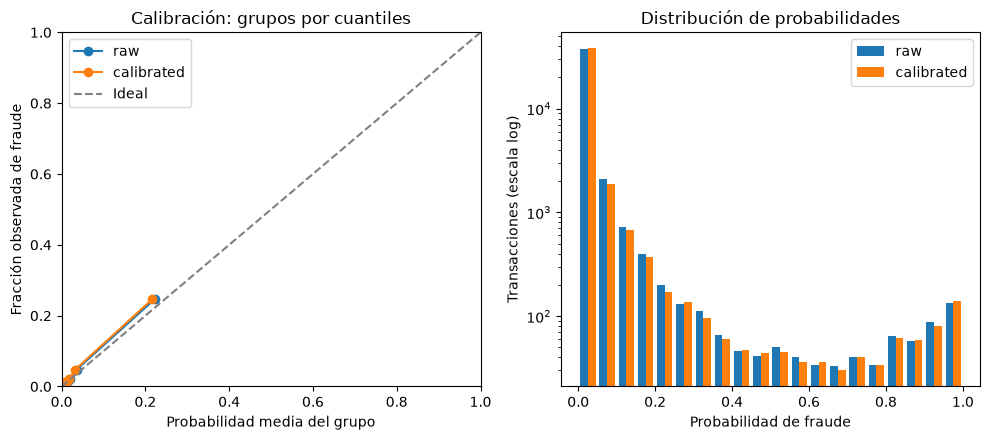

Modelo guardado; test sin puntuar; comparación económica pendiente.


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
for name, block in reliability.groupby('probabilities', sort=False):
    axes[0].plot(block.mean_probability, block.observed_rate, marker='o', label=name)
axes[0].plot([0, 1], [0, 1], '--', color='gray', label='Ideal')
axes[0].set(xlabel='Probabilidad media del grupo', ylabel='Fracción observada de fraude', title='Calibración: grupos por cuantiles', xlim=(0, 1), ylim=(0, 1))
axes[0].legend()
axes[1].hist([p_raw, p_calibrated], bins=20, range=(0, 1), label=['raw', 'calibrated'])
axes[1].set(xlabel='Probabilidad de fraude', ylabel='Transacciones (escala log)', title='Distribución de probabilidades', yscale='log')
axes[1].legend()
fig.tight_layout()
figure_path = ROOT / 'results/figures/reajuste_calibracion_validation.png'
figure_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(figure_path, dpi=160, bbox_inches='tight')
plt.show()
record = save_refit(ROOT, predictor, validation_policy, p_raw, p_calibrated, windows, diagnostics, metrics, reliability, calibration_fraction=CALIBRATION_FRACTION)
print('Modelo guardado; test sin puntuar; comparación económica pendiente.')


## 6. Lectura de esta corrida y alcance

En la corrida documentada, ambas representaciones alcanzan AP 0,4648. La pendiente del calibrador es positiva (1,0218), por lo que conserva el orden de las operaciones. La calibración no mejora los diagnósticos globales posteriores: Brier pasa de 0,024942 a 0,025003 y log-loss, de 0,100791 a 0,101156. Son diferencias pequeñas, sin una evaluación de incertidumbre estadística en esta etapa.

La prevalencia posterior es 3,6079%, mientras el riesgo medio pasa de 3,3019% a 3,1323%: la calibración amplía la subestimación global. Acerca los cinco grupos inferiores a sus frecuencias observadas, pero aumenta la discrepancia de los cinco superiores. El grupo superior resume riesgos calibrados de aproximadamente 0,0481 a 0,9950; su punto en la curva no demuestra precisión individual en ese rango.

A corte fijo 0,5, TP pasa de 432 a 423 y FP de 141 a 140. El cambio viene de la escala de probabilidad, no de optimizar el umbral. No interpretamos esas cantidades como ahorro sin incorporar montos y Ca.

Conservamos el predictor y calibrador como artefactos de desarrollo, sin afirmar que la calibración ya es suficiente para la decisión económica final. No escogemos retrospectivamente otro mapeo sobre esta misma ventana. Si discutimos una alternativa, deberá registrarse como otro experimento y no como confirmación independiente de esta corrida.

El informe docs/06_reajuste_y_calibracion.md desarrolla los resultados. Las métricas internas del 05 no son comparables directamente con esta ventana. No usamos este diagnóstico para volver a elegir retrospectivamente hiperparámetros o calibrador dentro de la misma corrida.

El paso siguiente será comparar decisiones económicas con estas probabilidades y la matriz original, documentando Ca como escenario hipotético mientras no exista una justificación acordada. Test sigue reservado, con la limitación histórica de consulta agregada de etiquetas descrita en el informe 02.
